In [1]:
import os 
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
train_path = "dataset/TRAIN"
test_path = "dataset/TEST"
classes = ["O", "R"]

In [3]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (64, 64))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    features = hog(gray,
                  orientations = 9,
                  pixels_per_cell = (8, 8),
                  cells_per_block = (2, 2),
                  block_norm = 'L2-Hys')
    return features

In [4]:
train_data = []
train_labels = []
for label in classes:
    folder = os.path.join(train_path, label)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            features = extract_features(img_path)
            train_data.append(features)
            train_labels.append(label)
        except:
            continue
X_train = np.array(train_data)
Y_train = np.array(train_labels)
print("Training images : ", len(X_train))

Training images :  22564


In [5]:
test_data = []
test_labels = []
for label in classes:
    folder = os.path.join(test_path, label)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try: 
            features = extract_features(img_path)
            test_data.append(features)
            test_labels.append(label)
        except:
            continue
X_test = np.array(test_data)
Y_test = np.array(test_labels)
print("Test images : ", len(X_test))

Test images :  2513


In [6]:
model = LinearSVC(class_weight = 'balanced')
model.fit(X_train, Y_train)
print("Model training completed")

Model training completed


In [7]:
Y_pred = model.predict(X_test)
print("Accuracy : ", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy :  0.7847194588141664
              precision    recall  f1-score   support

           O       0.78      0.85      0.82      1401
           R       0.79      0.70      0.74      1112

    accuracy                           0.78      2513
   macro avg       0.79      0.78      0.78      2513
weighted avg       0.79      0.78      0.78      2513



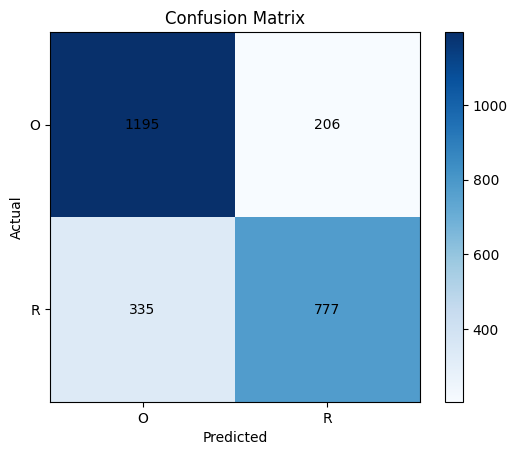

In [8]:
cm = confusion_matrix(Y_test, Y_pred)
plt.imshow(cm, cmap = "Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["O", "R"])
plt.yticks([0, 1], ["O", "R"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha = "center", va = "center")
plt.show()

In [9]:
joblib.dump(model, "model/svm_model.pkl")
print("Model saved successfully")

Model saved successfully


In [12]:
def predict_image(path):
    features = extract_features(path)
    prediction = model.predict([features])[0]
    
    if prediction == "O":
        return "Organic Waste"
    else:
        return "Recyclable Waste"
print(predict_image("dataset/TEST/O/O_12570.jpg"))

Organic Waste
